In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Load the committed Titanic CSV produced by 01_eda.ipynb
df_model = pd.read_csv("titanic.csv")

print("Dataset loaded from titanic.csv")
print("Shape:", df_model.shape)

Dataset loaded from titanic.csv
Shape: (891, 15)


In [4]:
sns.load_dataset("titanic")


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [5]:
# Select features and target
target = "survived"

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df_model[features].copy()
y = df_model[target].copy()

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target)

print("\nTarget class counts:")
print(y.value_counts())

print("\nTarget class proportions:")
print(y.value_counts(normalize=True))

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Target:
survived

Target class counts:
survived
0    549
1    342
Name: count, dtype: int64

Target class proportions:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [6]:
# Stratified train/test split BEFORE preprocessing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("===== TRAIN/TEST SPLIT =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))

===== TRAIN/TEST SPLIT =====
X_train: (712, 7)
X_test : (179, 7)
y_train: (712,)
y_test : (179,)

Training class proportions:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Testing class proportions:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## Stratified Train/Test Split

The dataset was divided into training and testing sets using an 80/20 stratified split. Stratification was used because the target variable `survived` contains two classes, and maintaining approximately the same class proportions in both the training and testing sets provides a more representative evaluation. The split was performed before any preprocessing to prevent information leakage.

In [7]:
# Define feature groups

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical features:
['sex', 'embarked']


In [ ]:


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [ ]:


categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [10]:
# Combine numeric and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [11]:
# Fit preprocessing ONLY on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data without fitting again
X_test_processed = preprocessor.transform(X_test)

print("Training processed shape:", X_train_processed.shape)
print("Testing processed shape:", X_test_processed.shape)

Training processed shape: (712, 10)
Testing processed shape: (179, 10)


In [17]:
preprocessor.fit_transform(X_train)
preprocessor.transform(X_test)


array([[ 0.82956755, -0.42686041,  1.42175336, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.82956755,  1.10969551, -0.46508428, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.82956755, -0.58051601, -0.46508428, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.37094484, -0.11954923, -0.46508428, ...,  0.        ,
         0.        ,  1.        ],
       [-0.37094484, -0.50368821, -0.46508428, ...,  1.        ,
         0.        ,  0.        ],
       [-0.37094484,  0.11093416,  0.47833454, ...,  0.        ,
         0.        ,  1.        ]], shape=(179, 10))

In [18]:
# Logistic Regression pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

logistic_pipeline.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [19]:
# Decision Tree pipeline

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=4
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [20]:
# Random Forest pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [21]:
# Get feature names after preprocessing

feature_names = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Processed feature names:")
print(feature_names)

Processed feature names:
['num__pclass' 'num__age' 'num__sibsp' 'num__parch' 'num__fare'
 'cat__sex_female' 'cat__sex_male' 'cat__embarked_C' 'cat__embarked_Q'
 'cat__embarked_S']


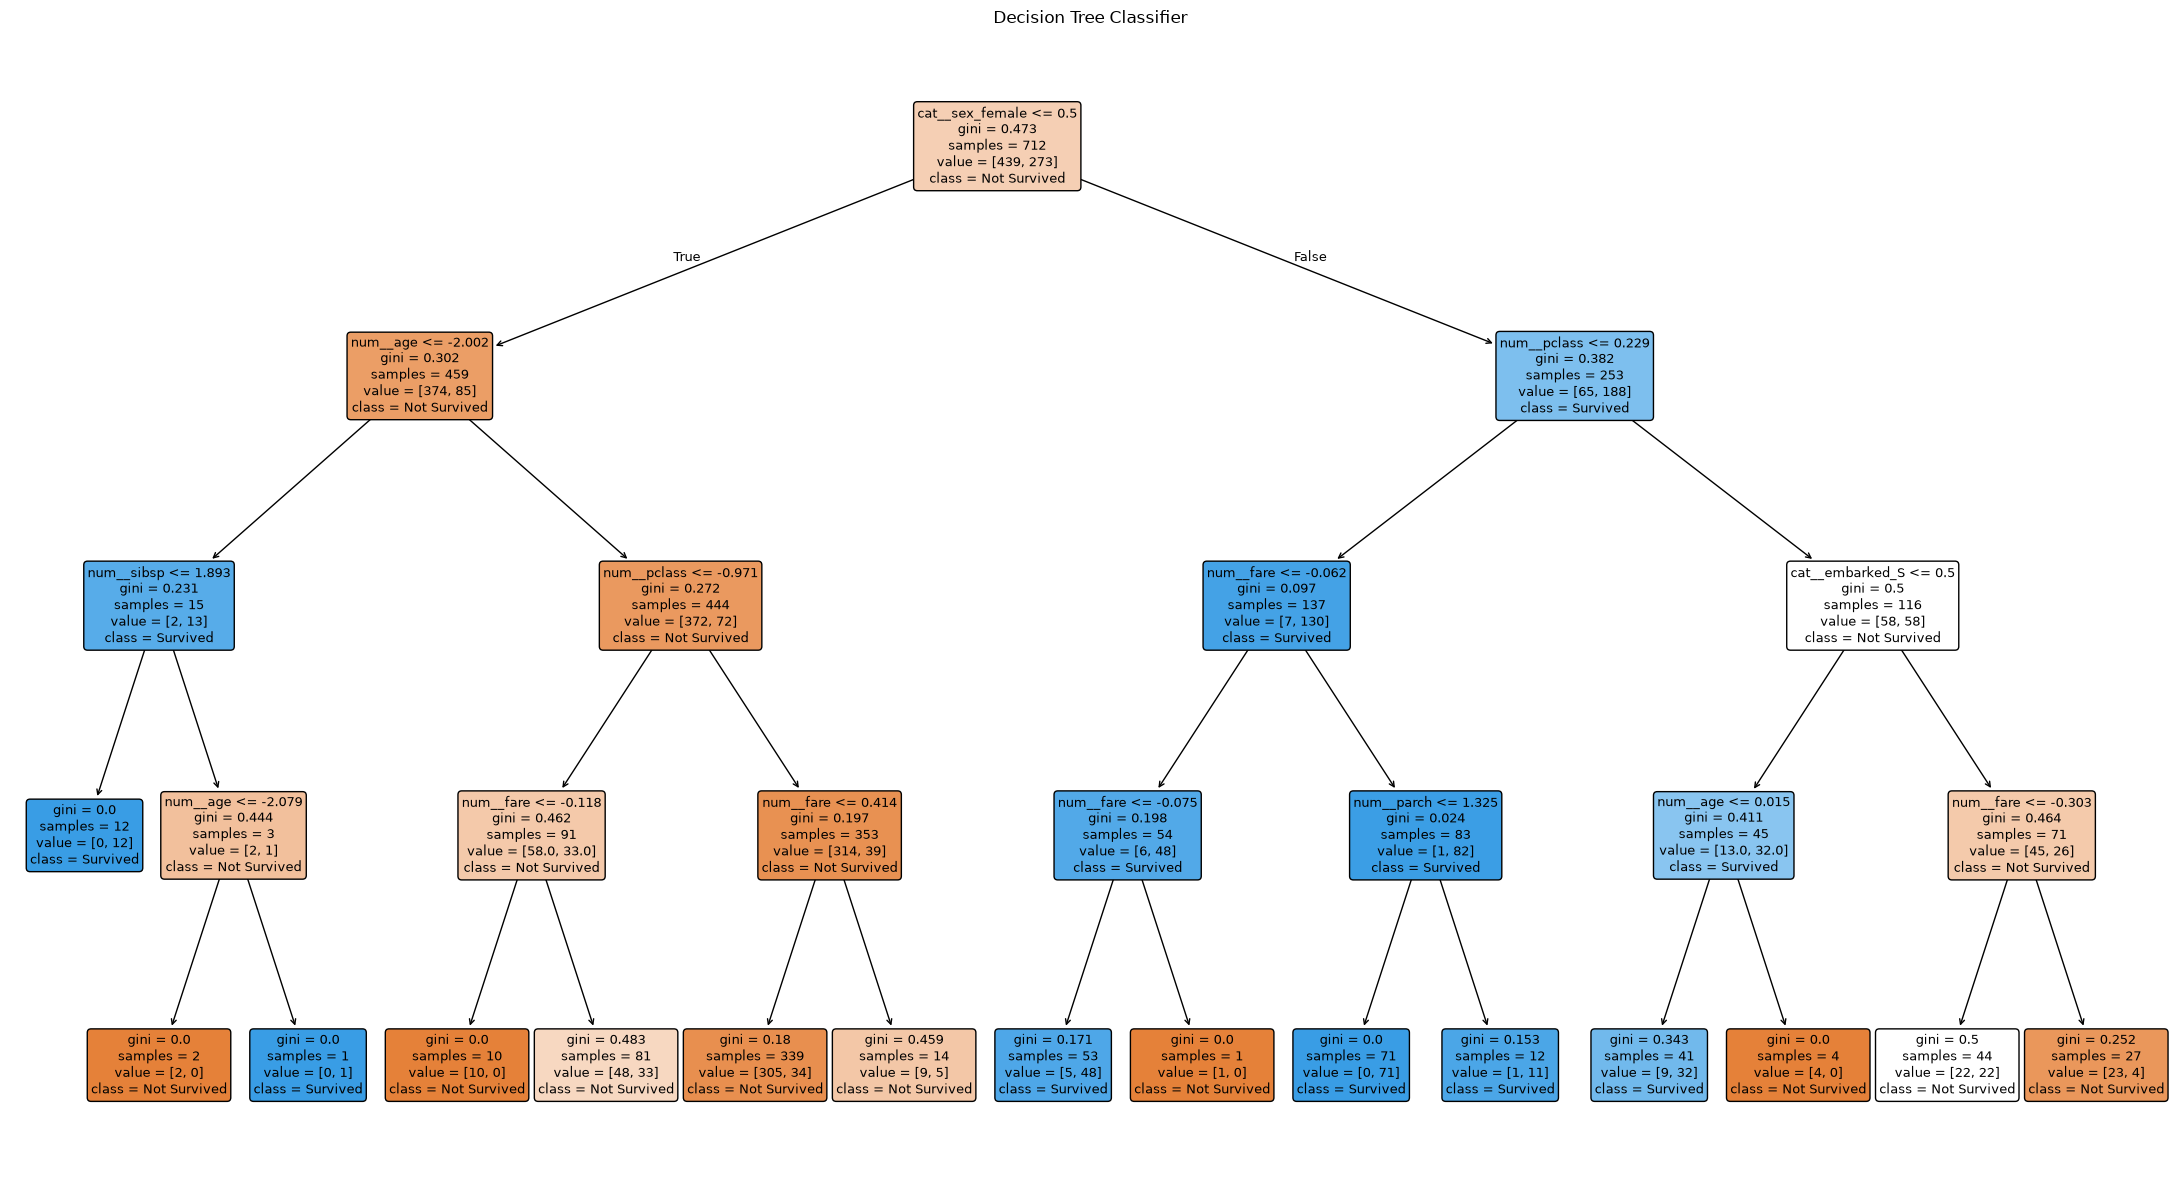

In [22]:
# Render the Decision Tree

tree_model = decision_tree_pipeline.named_steps["classifier"]

plt.figure(figsize=(22, 12))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree Classifier")
plt.tight_layout()

plt.savefig(
    "charts/decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [24]:
def evaluate_classifier(model, X_test, y_test, model_name):
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(cm)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    return {
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

In [25]:
logistic_results = evaluate_classifier(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)

tree_results = evaluate_classifier(
    decision_tree_pipeline,
    X_test,
    y_test,
    "Decision Tree"
)

forest_results = evaluate_classifier(
    random_forest_pipeline,
    X_test,
    y_test,
    "Random Forest"
)


===== Logistic Regression =====
Confusion Matrix:
[[98 12]
 [23 46]]
Accuracy : 0.8045
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244
AUC      : 0.8437

===== Decision Tree =====
Confusion Matrix:
[[104   6]
 [ 31  38]]
Accuracy : 0.7933
Precision: 0.8636
Recall   : 0.5507
F1 Score : 0.6726
AUC      : 0.8292

===== Random Forest =====
Confusion Matrix:
[[98 12]
 [21 48]]
Accuracy : 0.8156
Precision: 0.8000
Recall   : 0.6957
F1 Score : 0.7442
AUC      : 0.8287


In [26]:
classification_results = pd.DataFrame([
    logistic_results,
    tree_results,
    forest_results
])

print("===== CLASSIFICATION MODEL COMPARISON =====")
display(classification_results)

===== CLASSIFICATION MODEL COMPARISON =====


,model,accuracy,precision,recall,f1,auc
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Decision Tree,0.793296,0.863636,0.550725,0.672566,0.829249
2,Random Forest,0.815642,0.800000,0.695652,0.744186,0.828722


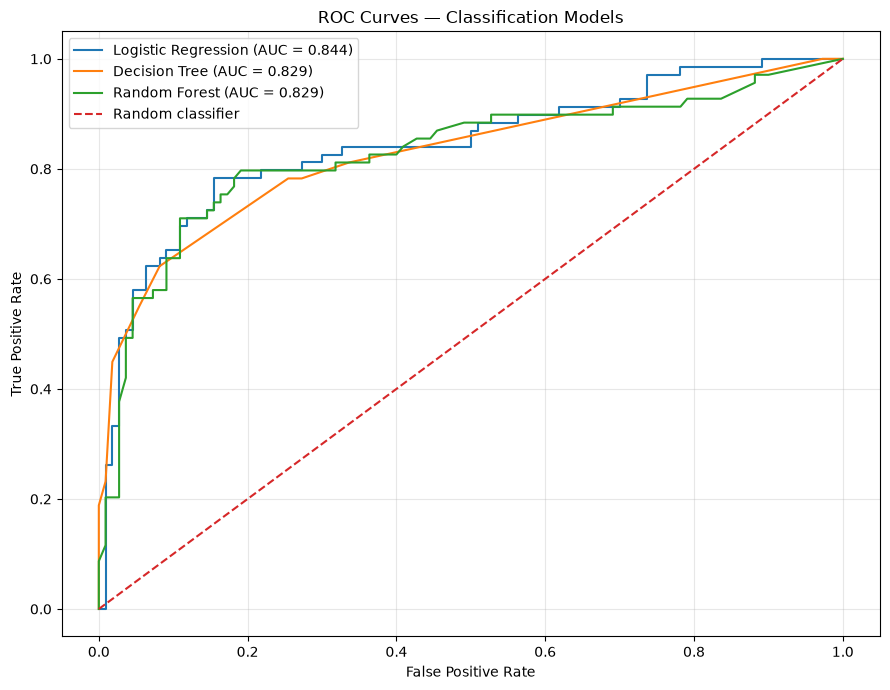

In [27]:
plt.figure(figsize=(9, 7))

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}

for model_name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classification Models")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "charts/roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

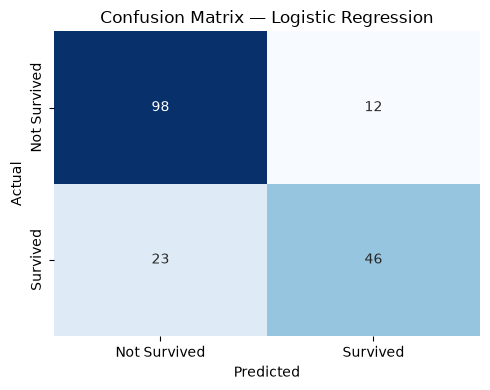

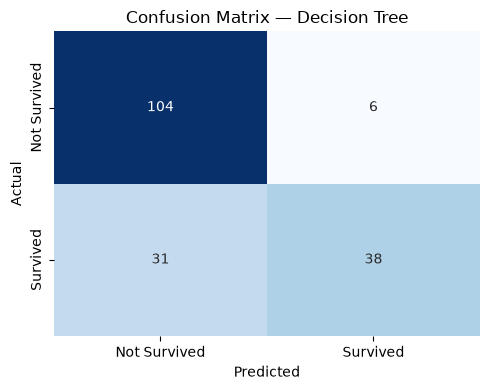

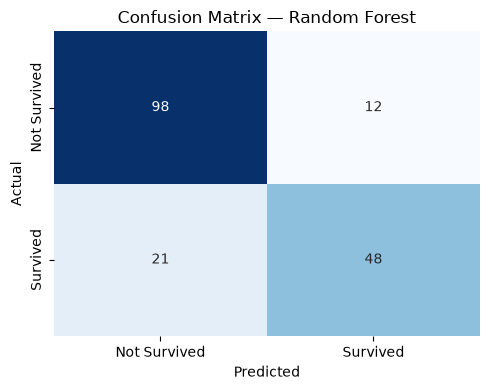

In [28]:
for model_name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Not Survived", "Survived"],
        yticklabels=["Not Survived", "Survived"]
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    filename = (
        model_name.lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"charts/confusion_matrix_{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
# Baseline Logistic Regression
# No class balancing or oversampling

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

baseline_precision = precision_score(y_test, baseline_pred)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print("===== BASELINE =====")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1 Score : {baseline_f1:.4f}")

===== BASELINE =====
Precision: 0.7931
Recall   : 0.6667
F1 Score : 0.7244


In [31]:
# Logistic Regression with class_weight='balanced'

balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)

balanced_precision = precision_score(
    y_test,
    balanced_pred
)

balanced_recall = recall_score(
    y_test,
    balanced_pred
)

balanced_f1 = f1_score(
    y_test,
    balanced_pred
)

print("===== CLASS WEIGHT = BALANCED =====")
print(f"Precision: {balanced_precision:.4f}")
print(f"Recall   : {balanced_recall:.4f}")
print(f"F1 Score : {balanced_f1:.4f}")

===== CLASS WEIGHT = BALANCED =====
Precision: 0.7297
Recall   : 0.7826
F1 Score : 0.7552


In [32]:
# Transform training data using the training-fitted preprocessor
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Before SMOTE:")
print("X_train:", X_train_processed.shape)
print("y_train:")
print(y_train.value_counts())

Before SMOTE:
X_train: (712, 10)
y_train:
survived
0    439
1    273
Name: count, dtype: int64


In [33]:
# Apply SMOTE ONLY to the training data

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("After SMOTE:")
print("X_train:", X_train_smote.shape)

print("\ny_train class counts:")
print(y_train_smote.value_counts())

After SMOTE:
X_train: (878, 10)

y_train class counts:
survived
1    439
0    439
Name: count, dtype: int64


In [34]:
# Train Logistic Regression using SMOTE-resampled training data

smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_pred = smote_model.predict(
    X_test_processed
)

smote_precision = precision_score(
    y_test,
    smote_pred
)

smote_recall = recall_score(
    y_test,
    smote_pred
)

smote_f1 = f1_score(
    y_test,
    smote_pred
)

print("===== SMOTE =====")
print(f"Precision: {smote_precision:.4f}")
print(f"Recall   : {smote_recall:.4f}")
print(f"F1 Score : {smote_f1:.4f}")

===== SMOTE =====
Precision: 0.7397
Recall   : 0.7826
F1 Score : 0.7606


In [35]:
imbalance_results = pd.DataFrame({
    "method": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "precision": [
        baseline_precision,
        balanced_precision,
        smote_precision
    ],
    "recall": [
        baseline_recall,
        balanced_recall,
        smote_recall
    ],
    "f1": [
        baseline_f1,
        balanced_f1,
        smote_f1
    ]
})

print("===== IMBALANCE COMPARISON =====")
display(imbalance_results)

===== IMBALANCE COMPARISON =====


,method,precision,recall,f1
0,Baseline,0.793103,0.666667,0.724409
1,Class Weight Balanced,0.729730,0.782609,0.755245
2,SMOTE,0.739726,0.782609,0.760563


### Task 11 — Class Imbalance Comparison

The baseline Logistic Regression model achieved the highest precision (0.7931), but its recall was lower at 0.6667. Using `class_weight='balanced'` increased recall to 0.7826, although precision decreased to 0.7297. SMOTE produced the same recall of 0.7826 while achieving slightly higher precision of 0.7397 and the highest F1-score of 0.7606. Therefore, in this comparison, SMOTE provided the strongest balance between precision and recall according to the F1-score.

In [36]:
from sklearn.model_selection import GridSearchCV

In [37]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        oob_score=True,
        n_jobs=-1
    ))
])

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

In [38]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__max_features": ["sqrt", "log2"]
}

In [39]:
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [40]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_au

In [41]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 100}

Best Cross-Validation F1 Score:
0.7459285142059674


In [42]:
best_rf_pipeline = grid_search.best_estimator_

best_rf_classifier = best_rf_pipeline.named_steps["classifier"]

print("OOB Score:")
print(best_rf_classifier.oob_score_)

OOB Score:
0.827247191011236


In [43]:
y_pred_tuned_rf = best_rf_pipeline.predict(X_test)

tuned_rf_accuracy = accuracy_score(y_test, y_pred_tuned_rf)
tuned_rf_precision = precision_score(y_test, y_pred_tuned_rf)
tuned_rf_recall = recall_score(y_test, y_pred_tuned_rf)
tuned_rf_f1 = f1_score(y_test, y_pred_tuned_rf)

y_prob_tuned_rf = best_rf_pipeline.predict_proba(X_test)[:, 1]
tuned_rf_auc = roc_auc_score(y_test, y_prob_tuned_rf)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", tuned_rf_accuracy)
print("Precision:", tuned_rf_precision)
print("Recall   :", tuned_rf_recall)
print("F1 Score :", tuned_rf_f1)
print("AUC      :", tuned_rf_auc)
print("OOB Score:", best_rf_classifier.oob_score_)

Tuned Random Forest Results
---------------------------
Accuracy : 0.8156424581005587
Precision: 0.875
Recall   : 0.6086956521739131
F1 Score : 0.717948717948718
AUC      : 0.8431488801054018
OOB Score: 0.827247191011236


### Task 12 — Random Forest Hyperparameter Tuning

GridSearchCV was used to tune the Random Forest hyperparameters `n_estimators`, `max_depth`, and `max_features` using 5-fold cross-validation. The search optimized F1-score because it provides a balance between precision and recall, which is relevant for the imbalanced survival target. The Random Forest was configured with `oob_score=True`, and the resulting OOB score was reported along with the best hyperparameters and test-set performance.

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [45]:
regression_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

X_reg = df_model[regression_features].copy()
y_reg = df_model["fare"].copy()

print("Regression features:")
print(regression_features)

print("\nX shape:", X_reg.shape)
print("y shape:", y_reg.shape)

Regression features:
['survived', 'pclass', 'age', 'sibsp', 'parch']

X shape: (891, 5)
y shape: (891,)


In [46]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training shape:", X_reg_train.shape)
print("Testing shape:", X_reg_test.shape)

Training shape: (712, 5)
Testing shape: (179, 5)


In [47]:
regression_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            regression_features
        )
    ]
)

In [48]:
regression_pipeline = Pipeline([
    ("preprocessor", regression_preprocessor),
    ("regressor", LinearRegression())
])

In [49]:
regression_pipeline.fit(X_reg_train, y_reg_train)

y_reg_pred = regression_pipeline.predict(X_reg_test)

print("Regression model trained successfully.")

Regression model trained successfully.


In [50]:
mae = mean_absolute_error(y_reg_test, y_reg_pred)

rmse = np.sqrt(
    mean_squared_error(y_reg_test, y_reg_pred)
)

r2 = r2_score(y_reg_test, y_reg_pred)

n = len(y_reg_test)
p = X_reg_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print("Regression Metrics")
print("-------------------")
print("MAE        :", mae)
print("RMSE       :", rmse)
print("R²         :", r2)
print("Adjusted R²:", adjusted_r2)

Regression Metrics
-------------------
MAE        : 19.830126730293475
RMSE       : 30.754061153484276
R²         : 0.38878494662659524
Adjusted R²: 0.37111977167360666


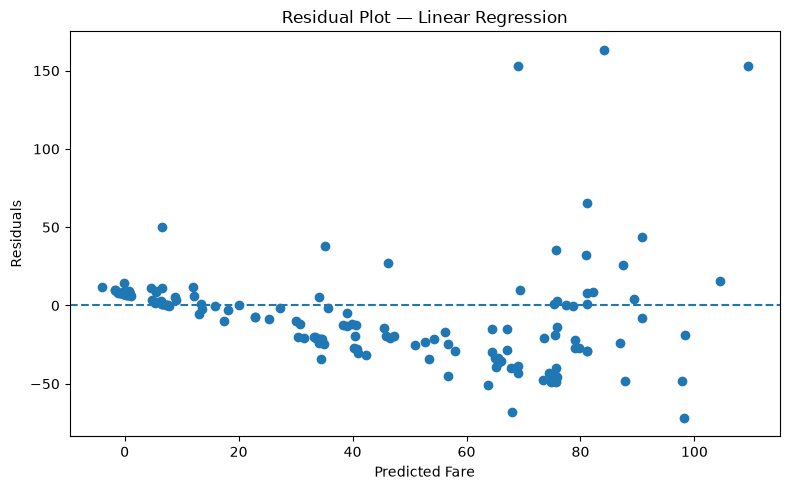

In [51]:
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_reg_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot — Linear Regression")
plt.tight_layout()

plt.savefig("charts/regression_residual_plot.png", dpi=300)
plt.show()

### Heteroscedasticity Conclusion

The residuals are distributed around the zero line without a clear funnel-shaped pattern. The spread of residuals is relatively similar across the predicted fare values, so there is no strong visual evidence of heteroscedasticity from the residual plot.

### Heteroscedasticity Conclusion

The residual plot shows a noticeable change in the spread of residuals as the predicted fare increases. This funnel-shaped pattern provides visual evidence of heteroscedasticity, indicating that the residual variance is not constant across the range of predicted fare values.

In [52]:
# Evaluate the three original classifiers again

final_classifiers = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Tuned Random Forest": best_rf_pipeline
}

final_results = []

for name, model in final_classifiers.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    })

final_classification_table = pd.DataFrame(final_results)

final_classification_table

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.843742
1,Decision Tree,0.793296,0.863636,0.550725,0.672566,0.829249
2,Random Forest,0.815642,0.800000,0.695652,0.744186,0.828722
3,Tuned Random Forest,0.815642,0.875000,0.608696,0.717949,0.843149


In [53]:
final_regression_table = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²", "Adjusted R²"],
    "Value": [
        mae,
        rmse,
        r2,
        adjusted_r2
    ]
})

final_regression_table

,Metric,Value
0,MAE,19.830127
1,RMSE,30.754061
2,R²,0.388785
3,Adjusted R²,0.371120


In [54]:
final_classification_table.to_csv(
    "charts/final_classification_comparison.csv",
    index=False
)

final_regression_table.to_csv(
    "charts/final_regression_metrics.csv",
    index=False
)

print("Final comparison tables saved successfully.")

Final comparison tables saved successfully.


In [55]:
best_f1_model = final_classification_table.loc[
    final_classification_table["F1"].idxmax()
]

best_auc_model = final_classification_table.loc[
    final_classification_table["AUC"].idxmax()
]

print("Highest F1:")
print(best_f1_model)

print("\nHighest AUC:")
print(best_auc_model)

Highest F1:
Model        Random Forest
Accuracy          0.815642
Precision              0.8
Recall            0.695652
F1                0.744186
AUC               0.828722
Name: 2, dtype: object

Highest AUC:
Model        Logistic Regression
Accuracy                0.804469
Precision               0.793103
Recall                  0.666667
F1                      0.724409
AUC                     0.843742
Name: 0, dtype: object


## Task 14 — Final Model Comparison

### Classification Models

The classification models were compared using accuracy, precision, recall, F1-score, and ROC-AUC on the same test set. The tuned Random Forest was also included to assess whether hyperparameter tuning improved performance compared with the original classifiers.

### Regression Model

The Linear Regression model was evaluated separately using MAE, RMSE, R², and Adjusted R². The model achieved an MAE of 19.8301, RMSE of 30.7541, R² of 0.3888, and Adjusted R² of 0.3711. The residual analysis showed visual evidence of heteroscedasticity.

In [56]:
import joblib

In [57]:
model_path = "models/best_titanic_classifier.joblib"

joblib.dump(
    random_forest_pipeline,
    model_path
)

print("Complete pipeline saved successfully.")
print("Saved to:", model_path)

Complete pipeline saved successfully.
Saved to: models/best_titanic_classifier.joblib


In [58]:
loaded_pipeline = joblib.load(model_path)

print("Pipeline reloaded successfully.")
print(loaded_pipeline)

Pipeline reloaded successfully.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                 

In [59]:
loaded_predictions = loaded_pipeline.predict(X_test)

print("First 10 predictions:")
print(loaded_predictions[:10])

First 10 predictions:
[0 0 0 0 1 0 1 1 0 0]


In [60]:
original_predictions = random_forest_pipeline.predict(X_test)

predictions_match = np.array_equal(
    original_predictions,
    loaded_predictions
)

print("Predictions match:", predictions_match)

Predictions match: True


In [61]:
sample_raw = X_test.head(5)

sample_predictions = loaded_pipeline.predict(sample_raw)

print("Raw input:")
display(sample_raw)

print("Predictions:")
print(sample_predictions)

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked
565,3,male,24.0,2,0,24.1500,S
160,3,male,44.0,0,1,16.1000,S
553,3,male,22.0,0,0,7.2250,C
860,3,male,41.0,2,0,14.1083,S
241,3,female,NaN,1,0,15.5000,Q


Predictions:
[0 0 0 0 1]


## Task 15 — Save and Reload Complete Pipeline

The selected Random Forest classifier was saved as a single Joblib object containing both the preprocessing steps and the classifier. The saved pipeline was successfully reloaded using `joblib.load()`. Predictions generated by the reloaded pipeline matched the predictions from the original pipeline, confirming that the complete preprocessing and modeling workflow was preserved. The reloaded pipeline also successfully generated predictions directly from raw test input without requiring manual preprocessing.